# Employee Attrition Prediction using Decision Tree
## Complete Classification & Model Evaluation Project

Dataset: IBM HR Analytics Employee Attrition

## Learning Objectives
- Exploratory Data Analysis
- Data Preprocessing
- Label Encoding
- Train/Test Split
- Decision Tree Classifier
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1 Score
- Classification Report
- ROC Curve
- ROC-AUC Score
- Precision-Recall Curve
- Feature Importance
- Decision Tree Visualization


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, auc
)


## Upload Dataset

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data Understanding

In [4]:
df.shape
df.info()
df.describe(include='all')
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

np.int64(0)

## Basic EDA

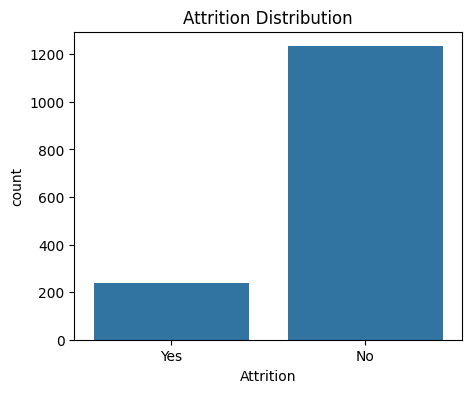

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,x='Attrition')
plt.title('Attrition Distribution')
plt.show()

## Drop Unnecessary Columns

In [6]:
drop_cols=['EmployeeCount','EmployeeNumber','Over18','StandardHours']
drop_cols=[c for c in drop_cols if c in df.columns]
df=df.drop(columns=drop_cols)

## Label Encoding

In [7]:
encoder=LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col]=encoder.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


## Split Features and Target

In [8]:
X=df.drop('Attrition',axis=1)
y=df['Attrition']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)


## Train Decision Tree

In [9]:
model=DecisionTreeClassifier(random_state=42,max_depth=5)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)[:,1]


## Confusion Matrix

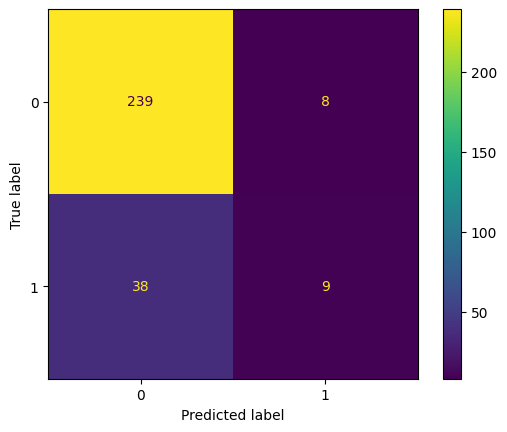

In [10]:
cm=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

## Accuracy

In [11]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8435374149659864


## Precision

In [12]:
print("Precision:",precision_score(y_test,y_pred))

Precision: 0.5294117647058824


## Recall

In [13]:
print("Recall:",recall_score(y_test,y_pred))

Recall: 0.19148936170212766


## F1 Score

In [14]:
print("F1 Score:",f1_score(y_test,y_pred))

F1 Score: 0.28125


## Classification Report

In [15]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       247
           1       0.53      0.19      0.28        47

    accuracy                           0.84       294
   macro avg       0.70      0.58      0.60       294
weighted avg       0.81      0.84      0.81       294



## ROC Curve & ROC-AUC

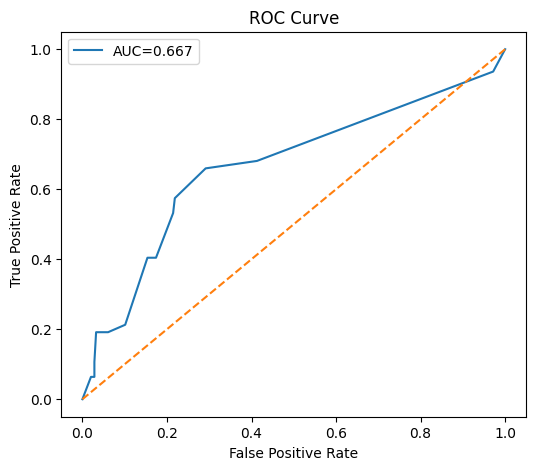

ROC-AUC: 0.66650874321647


In [16]:
fpr,tpr,thr=roc_curve(y_test,y_prob)
roc=roc_auc_score(y_test,y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f"AUC={roc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:",roc)


## Precision-Recall Curve

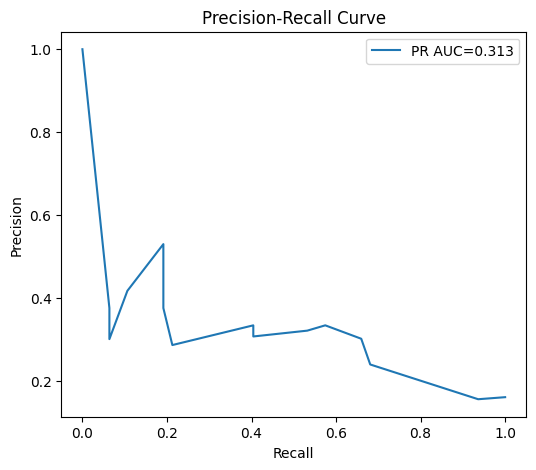

PR AUC: 0.3126645706070975


In [17]:
precision,recall,thr=precision_recall_curve(y_test,y_prob)
pr_auc=auc(recall,precision)

plt.figure(figsize=(6,5))
plt.plot(recall,precision,label=f"PR AUC={pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print("PR AUC:",pr_auc)


## Feature Importance

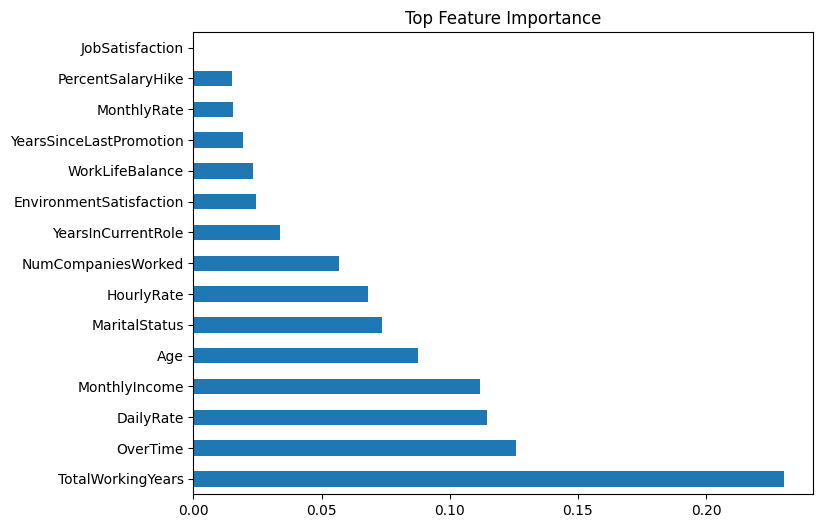

TotalWorkingYears          0.230443
OverTime                   0.125711
DailyRate                  0.114730
MonthlyIncome              0.111821
Age                        0.087616
MaritalStatus              0.073757
HourlyRate                 0.067997
NumCompaniesWorked         0.056752
YearsInCurrentRole         0.033951
EnvironmentSatisfaction    0.024576
WorkLifeBalance            0.023130
YearsSinceLastPromotion    0.019380
MonthlyRate                0.015278
PercentSalaryHike          0.014859
JobSatisfaction            0.000000
dtype: float64

In [18]:
fi=pd.Series(model.feature_importances_,index=X.columns)
fi=fi.sort_values(ascending=False)

plt.figure(figsize=(8,6))
fi.head(15).plot(kind='barh')
plt.title("Top Feature Importance")
plt.show()

fi.head(15)


## Decision Tree Visualization

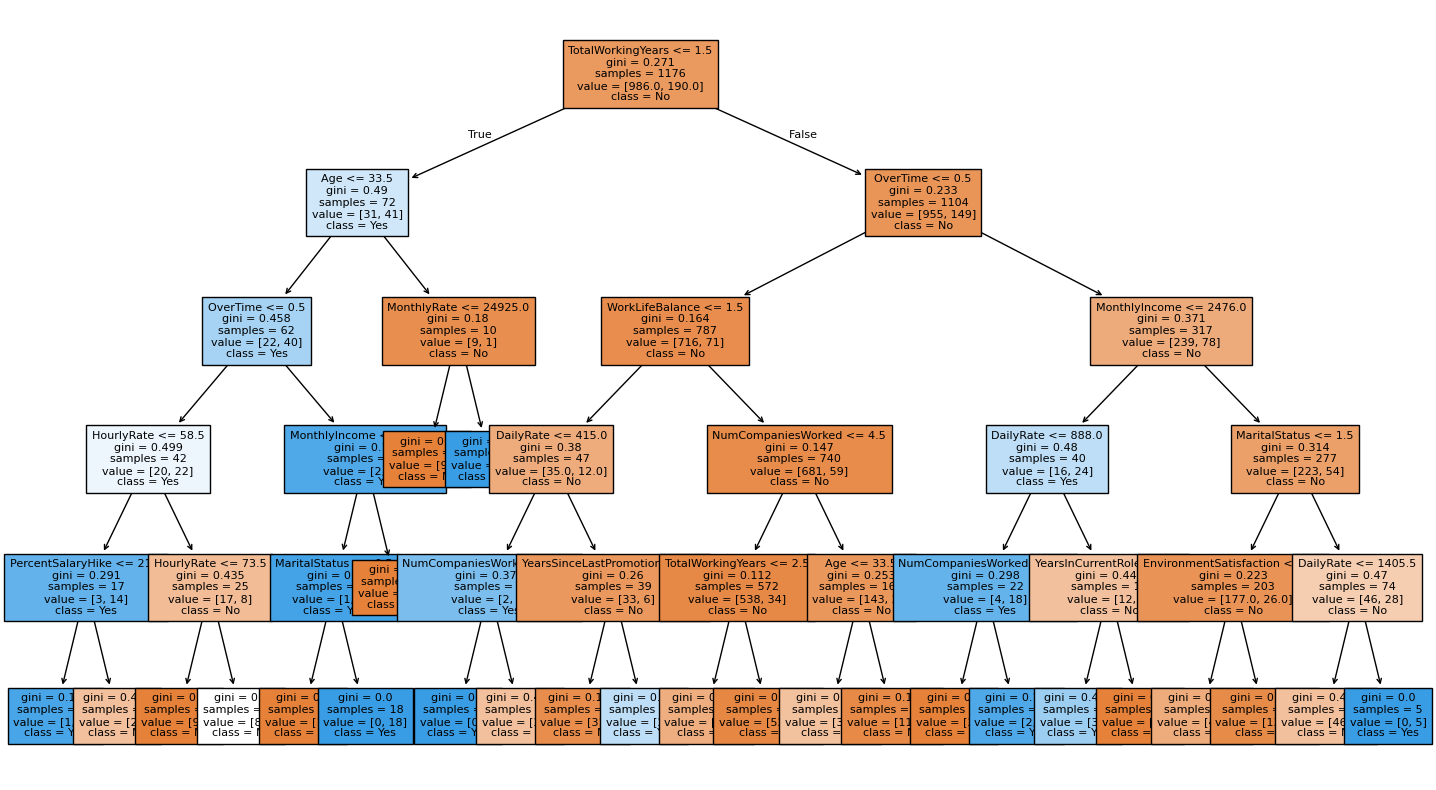

In [19]:
plt.figure(figsize=(18,10))
plot_tree(model,
          feature_names=X.columns,
          class_names=['No','Yes'],
          filled=True,
          fontsize=8)
plt.show()